# 🧠 Ejercicio Práctico: Consultas SQL en SDSS
Este notebook contiene instrucciones para realizar una consulta SQL en el Sloan Digital Sky Survey (SDSS) y analizar los resultados.

## 📚 Introducción
SDSS es una base de datos astronómica pública que permite acceder a millones de objetos del cielo a través del lenguaje SQL. En este ejercicio usarás SkyServer para filtrar galaxias brillantes en una región definida y visualizar sus propiedades fotométricas.

In [1]:
# Instalar si es necesario
!pip install astroquery


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.4/999.4 kB 30.3 MB/s eta 0:00:00


## 📥 Carga y visualización de resultados

In [41]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt

# Definir query SQL como string
query = """
SELECT
  p.objid, p.ra, p.dec, p.r, p.g, p.i, p.u, p.z
FROM PhotoObj AS p
WHERE p.type = 3  -- tipo = 3 corresponde a galaxias
  AND ra BETWEEN 184 AND 188
  AND dec BETWEEN 10 AND 15
  AND p.r < 20

"""


# Ejecutar la consulta
results = SDSS.query_sql(query)

# Convertir resultados a pandas DataFrame
df = results.to_pandas()
df

,objid,ra,dec,r,g,i,u,z
0,1237658630230900788,184.002086,12.686293,16.72013,18.03015,16.19457,21.64542,15.76922
1,1237658634525081816,184.002099,12.686275,16.87528,18.29949,16.27668,24.55605,15.74420
2,1237661812811300999,184.002110,12.686275,16.96182,18.70602,16.32493,23.78689,15.94609
3,1237658629157159281,184.002696,11.891728,18.37348,19.22812,17.92926,20.44824,17.61423
4,1237661949180379299,184.002736,11.891710,18.29210,19.13495,17.87410,20.36937,17.52777
...,...,...,...,...,...,...,...,...
47805,1237658629695734480,187.999664,12.297379,19.82013,21.33869,19.21785,23.91228,18.71764
47806,1237660615592050841,187.999789,11.041966,18.42104,19.33607,18.05880,20.96223,17.73497
47807,1237662239078351040,187.999797,11.041952,18.46336,19.35342,18.06623,21.30819,17.71333
47808,1237661948645212742,187.999948,11.582865,19.53652,20.78572,18.88530,22.14705,18.43242


## 📊 Diagrama color-magnitud

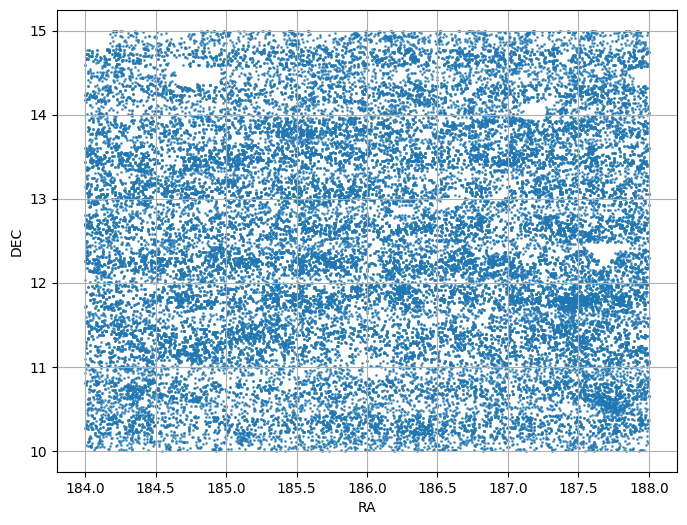

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(df['ra'], df['dec'], s=1, alpha=0.7)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.grid(True)
plt.show()

In [57]:
query = """
SELECT
  s.specobjid, s.z, p.objid, p.ra, p.dec, p.r, p.g, p.i
FROM SpecObj AS s
JOIN PhotoObj AS p ON s.bestobjid = p.objid
WHERE s.z < 0.01        -- redshift bajo (cercano a Virgo)
  AND p.r < 20          -- magnitudes brillantes
  AND p.type = 3        -- galaxias
  AND p.ra BETWEEN 184 AND 188
  AND p.dec BETWEEN 11 AND 14
"""
# Ejecutar la consulta
results = SDSS.query_sql(query)

# Convertir resultados a pandas DataFrame
df = results.to_pandas()
df.head()

,specobjid,z,objid,ra,dec,r,g,i
0,1816217614364469248,0.002737,1237661950254514505,184.801894,12.851872,16.19986,16.86421,15.91943
1,1988353037562832896,-0.000833,1237661068189368384,184.809300,13.882384,15.27727,15.64917,15.12976
2,1816078526143555584,0.000809,1237658628620877914,185.417989,11.503144,12.96408,13.36092,12.79768
3,1816079900533090304,0.004353,1237658629157879853,185.631909,11.802546,16.48896,17.14146,16.18461
4,1817256927814510592,0.007681,1237658629694881810,186.006225,12.204800,12.68032,13.09512,12.49961


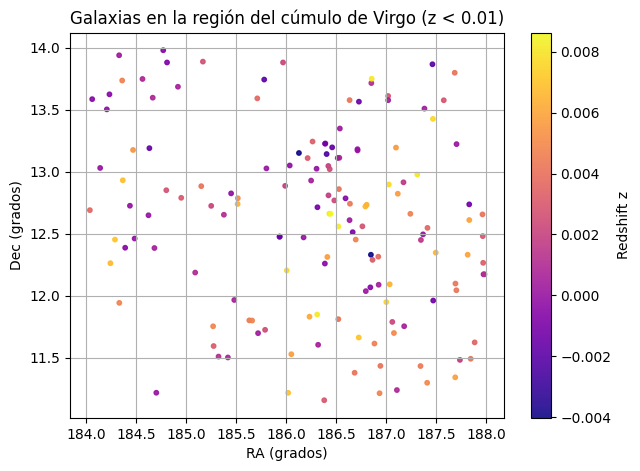

In [58]:
plt.figure(figsize=(7, 5))
plt.scatter(df['ra'], df['dec'], s=10, c=df['z'], cmap='plasma', alpha=0.9)
plt.xlabel("RA (grados)")
plt.ylabel("Dec (grados)")
plt.title("Galaxias en la región del cúmulo de Virgo (z < 0.01)")
plt.colorbar(label="Redshift z")
plt.grid(True)
plt.show()

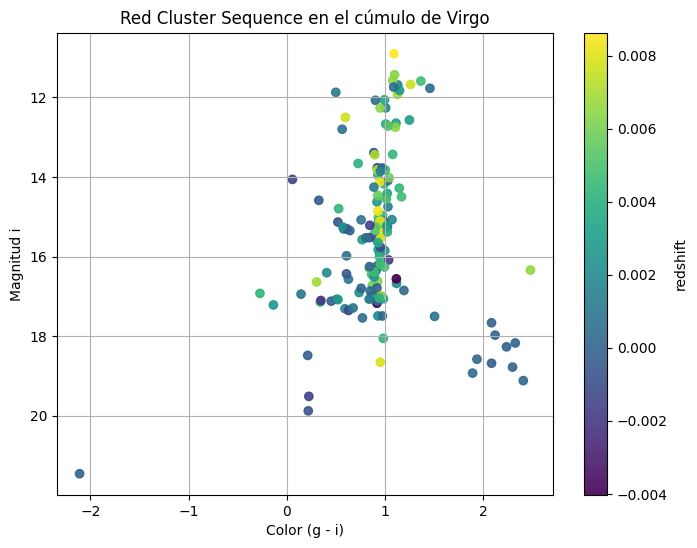

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(df['g']-df['i'], df['i'],alpha=0.9,c=df['z'])
plt.colorbar(label='redshift')
# Estética del gráfico
plt.gca().invert_yaxis()
plt.xlabel("Color (g - i)")
plt.ylabel("Magnitud i")
plt.title("Red Cluster Sequence en el cúmulo de Virgo")
plt.grid(True)
plt.show()

## 🧠 Preguntas para reflexionar

1. ¿Qué puedes decir de la distribución de colores y magnitudes?
2. ¿Observas agrupaciones o secuencias típicas?
3. ¿Cómo podrías modificar la consulta para observar estrellas o cuásares en lugar de galaxias?
